# Practice Task - Data Exploration and Cleaning
The objective of this practice task is to perform data exploration and cleaning in the given dataset.

Installing pyspark

In [ ]:
!pip install pyspark

Importing the needed modules and creating the spark session

In [ ]:
# importing spark session
from pyspark.sql import SparkSession

# data visualization modules
import matplotlib.pyplot as plt
import plotly.express as px

# pandas module
import pandas as pd

# pyspark SQL functions
from pyspark.sql.functions import col, when, count

# creating the spark session
spark = SparkSession.builder.appName("Customer_Churn_Prediction").getOrCreate()
spark

Loading the `parctice-dataset.csv` file

In [ ]:
data = spark.read.format('csv').option('header',True).option('inferSchema',True).load('Practice_dataset.csv')
data.show()


+----------+------------+------------+------------+------------+----------------+
|EmployeeID|        KPI1|        KPI2|        KPI3|        KPI4|Current Employee|
+----------+------------+------------+------------+------------+----------------+
|         0|-1.039682384|-0.716426478|-0.513467693| 0.414661471|               0|
|         1| 0.237093465|-0.820123996|-0.865801274| 0.438661047|               0|
|         2|-2.077948003| 0.185688029|-0.132418305| 0.711280402|               1|
|         3|-0.684711628| 1.522335039| 1.674082146|-1.234292085|               1|
|         4|-1.137117653|-0.555136531|-0.176780706|-1.776008972|               0|
|         5|-1.052934587| 0.119522573|-0.188215465|-0.867239924|               1|
|         6| 0.953745557| 0.738929252|   0.6416214|-1.069803493|               1|
|         7|-0.623751805| 1.770892731| 2.084658776| 0.436191916|               1|
|         8| 0.998210721| -0.74099461|-0.356348072|-1.950751965|               0|
|         9| 0.7

How many rows and columns do we have in the dataset?

In [ ]:
print(data.count(), "Rows")
print(len(data.columns), "Columns")

10000 Rows
6 Columns


Create a histogram matrix to analyse the distributions of the numerical columns.

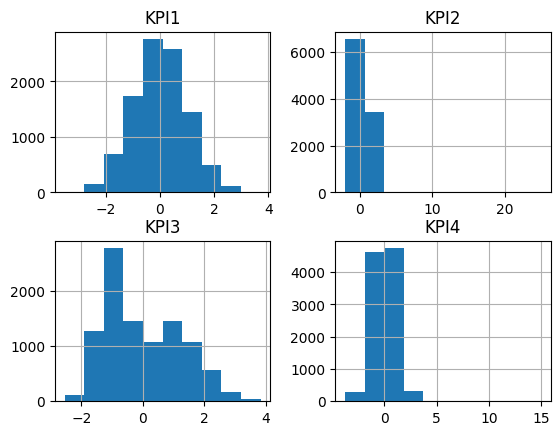

In [ ]:
df = data.select(["KPI1", "KPI2", "KPI3", "KPI4"]).toPandas()
df.hist()
plt.show()

Observe the distributions of the numerical columns in the histograms generated in the previous part.
- Find the columns with outilers
- Remove the outliers

In [ ]:
# Removing the outlier in KPI2 column
data = data.filter(data.KPI2 < 5)

# Removing the outlier in KPI4 column
data = data.filter(data.KPI4 < 5)

# Make sure that the outliers are deleted
data.count()

9995

Find the missing values in the dataset.

In [ ]:
for c in data.columns:
    data.select(count(when(col(c).isNull(), c)).alias(c)).show()

+----------+
|EmployeeID|
+----------+
|         0|
+----------+

+----+
|KPI1|
+----+
|   4|
+----+

+----+
|KPI2|
+----+
|   0|
+----+

+----+
|KPI3|
+----+
|   2|
+----+

+----+
|KPI4|
+----+
|   0|
+----+

+----------------+
|Current Employee|
+----------------+
|               0|
+----------------+



Use **Mean Imputer** to fill the missing values

In [ ]:
from pyspark.ml.feature import Imputer

columns_with_missing_values = ["KPI1", "KPI3", "KPI4"]
imputer = Imputer(inputCols = columns_with_missing_values, outputCols = columns_with_missing_values).setStrategy("mean")
imputer = imputer.fit(data)
data = imputer.transform(data)
data.show()

+----------+------------+------------+------------+------------+----------------+
|EmployeeID|        KPI1|        KPI2|        KPI3|        KPI4|Current Employee|
+----------+------------+------------+------------+------------+----------------+
|         0|-1.039682384|-0.716426478|-0.513467693| 0.414661471|               0|
|         1| 0.237093465|-0.820123996|-0.865801274| 0.438661047|               0|
|         2|-2.077948003| 0.185688029|-0.132418305| 0.711280402|               1|
|         3|-0.684711628| 1.522335039| 1.674082146|-1.234292085|               1|
|         4|-1.137117653|-0.555136531|-0.176780706|-1.776008972|               0|
|         5|-1.052934587| 0.119522573|-0.188215465|-0.867239924|               1|
|         6| 0.953745557| 0.738929252|   0.6416214|-1.069803493|               1|
|         7|-0.623751805| 1.770892731| 2.084658776| 0.436191916|               1|
|         8| 0.998210721| -0.74099461|-0.356348072|-1.950751965|               0|
|         9| 0.7

Again, find the missing values in the dataset to make sure no missing value exists.

In [ ]:
for c in data.columns:
    data.select(count(when(col(c).isNull(), c)).alias(c)).show()

+----------+
|EmployeeID|
+----------+
|         0|
+----------+

+----+
|KPI1|
+----+
|   0|
+----+

+----+
|KPI2|
+----+
|   0|
+----+

+----+
|KPI3|
+----+
|   0|
+----+

+----+
|KPI4|
+----+
|   0|
+----+

+----------------+
|Current Employee|
+----------------+
|               0|
+----------------+

